# Cleveland Levy Policy Example

This notebook follows the same step structure as the other city notebooks in this repo. It documents the Cleveland-specific implementation choices from `LVT_MODELING_GUIDE.md`, loads parcel data from Cuyahoga County's official GIS services, recreates the current Cleveland city levy, models several LVT scenarios, and produces the same style of property-category and census progressivity charts used in Spokane, Syracuse, Baltimore, and St. Paul.


In [1]:
import os
import sys
import time
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from dotenv import load_dotenv
from shapely.geometry import Polygon

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lvt_utils.py").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

load_dotenv(REPO_ROOT / ".env")

from census_utils import get_census_data_with_boundaries, match_to_census_blockgroups
from lvt_utils import (
    calculate_category_tax_summary,
    calculate_current_tax,
    model_split_rate_tax,
    print_category_tax_summary,
)
from policy_analysis import (
    analyze_parking_lots,
    analyze_vacant_land,
    print_parking_analysis_summary,
    print_vacant_land_summary,
)
from viz import calculate_block_group_summary

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)


In [2]:
data_dir = REPO_ROOT / "examples" / "data" / "cleveland"
data_dir.mkdir(parents=True, exist_ok=True)

parcel_query_url = "https://gis.cuyahogacounty.us/server/rest/services/MyPLACE/Parcels_WMA_GJOIN_WGS84/MapServer/2/query"
rate_query_url = "https://gis.cuyahogacounty.us/server/rest/services/Hosted/CertEffRates2021/FeatureServer/0/query"
cleveland_where = "par_city='CLEVELAND'"

attrs_cache = data_dir / "cleveland_attrs_20260310.parquet"
geometry_cache = data_dir / "cleveland_geometry_20260310.parquet"

attr_fields = [
    "objectid",
    "parcel_id",
    "par_addr_all",
    "par_city",
    "parcel_owner",
    "tax_luc",
    "tax_luc_description",
    "property_class",
    "tax_district",
    "neighborhood_code",
    "condo_complex_id",
    "tax_abatement",
    "tax_year",
    "parcel_year",
    "certified_tax_land",
    "certified_tax_building",
    "certified_tax_total",
    "certified_exempt_land",
    "certified_exempt_building",
    "certified_exempt_total",
    "certified_abated_land",
    "certified_abated_building",
    "certified_abated_total",
    "gross_certified_land",
    "gross_certified_building",
    "gross_certified_total",
    "res_bldg_count",
    "com_bldg_count",
    "com_living_units",
    "total_res_liv_area",
    "total_com_use_area",
    "total_square_ft",
    "total_acreage",
]


def fetch_arcgis_records(query_url, where, out_fields, chunk_size=1000, return_geometry=False):
    session = requests.Session()
    count_resp = session.get(
        query_url,
        params={"f": "json", "where": where, "returnCountOnly": "true"},
        timeout=60,
    )
    count_resp.raise_for_status()
    total_records = count_resp.json()["count"]
    print(f"Total records matching filter: {total_records:,}")

    rows = []
    for offset in range(0, total_records, chunk_size):
        params = {
            "f": "json",
            "where": where,
            "outFields": ",".join(out_fields),
            "returnGeometry": str(return_geometry).lower(),
            "resultOffset": offset,
            "resultRecordCount": chunk_size,
            "orderByFields": "objectid ASC",
        }
        if return_geometry:
            params["outSR"] = 4326
            params["geometryPrecision"] = 6

        response = session.get(query_url, params=params, timeout=180)
        response.raise_for_status()
        payload = response.json()
        features = payload.get("features", [])
        if not features:
            break
        rows.extend(features)
        if offset == 0 or ((offset // chunk_size) + 1) % 25 == 0 or offset + chunk_size >= total_records:
            print(f"Fetched {min(offset + len(features), total_records):,} / {total_records:,}")

    return rows


def esri_polygon_to_shapely(geometry_dict):
    rings = geometry_dict.get("rings", [])
    if not rings:
        return None
    if len(rings) == 1:
        return Polygon(rings[0])
    return Polygon(rings[0], holes=rings[1:])


def load_attrs():
    if attrs_cache.exists():
        print(f"Loading attribute cache: {attrs_cache.name}")
        return pd.read_parquet(attrs_cache)

    features = fetch_arcgis_records(parcel_query_url, cleveland_where, attr_fields, chunk_size=1000)
    df = pd.DataFrame([feature["attributes"] for feature in features])
    df = df.drop_duplicates(subset=["objectid"]).sort_values("objectid").reset_index(drop=True)
    df.to_parquet(attrs_cache, index=False)
    print(f"Saved attribute cache: {attrs_cache.name}")
    return df


def load_geometry():
    if geometry_cache.exists():
        print(f"Loading geometry cache: {geometry_cache.name}")
        return gpd.read_parquet(geometry_cache)

    features = fetch_arcgis_records(
        parcel_query_url,
        cleveland_where,
        ["objectid", "parcel_id"],
        chunk_size=1000,
        return_geometry=True,
    )
    rows = []
    for feature in features:
        attrs = feature["attributes"]
        geom = esri_polygon_to_shapely(feature["geometry"])
        rows.append(
            {
                "objectid": attrs["objectid"],
                "parcel_id": attrs["parcel_id"],
                "geometry": geom,
            }
        )
    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")
    gdf = gdf.drop_duplicates(subset=["objectid"]).sort_values("objectid").reset_index(drop=True)
    gdf.to_parquet(geometry_cache, index=False)
    print(f"Saved geometry cache: {geometry_cache.name}")
    return gdf


## Step 1: Load Parcel Data

Cleveland parcel data comes from the Cuyahoga County `MyPlace` ArcGIS REST service:

- Base service: `https://gis.cuyahogacounty.us/server/rest/services/MyPLACE/Parcels_WMA_GJOIN_WGS84/MapServer`
- Parcel layer: `2`
- Geographic filter: `par_city = 'CLEVELAND'`

This is a county-wide dataset, so Cleveland parcels are filtered from the county service. Pagination is required. The main parcel table already includes gross values, taxable values, exemptions, and abatements. The Cleveland city levy rate comes from Cuyahoga County's certified effective-rate table and is constant at `12.7` mills across Cleveland tax districts `740`, `750`, and `760`.


In [3]:
parcel_attrs = load_attrs()
parcel_geometry = load_geometry()

gdf = parcel_geometry.merge(parcel_attrs, on=["objectid", "parcel_id"], how="inner")
gdf = gdf.drop_duplicates(subset=["objectid"]).sort_values("objectid").reset_index(drop=True)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

print(gdf.shape)
display(gdf.head(3))


Loading attribute cache: cleveland_attrs_20260310.parquet


Loading geometry cache: cleveland_geometry_20260310.parquet


(158545, 34)


,objectid,parcel_id,geometry,par_addr_all,par_city,parcel_owner,tax_luc,tax_luc_description,property_class,tax_district,neighborhood_code,condo_complex_id,tax_abatement,tax_year,parcel_year,certified_tax_land,certified_tax_building,certified_tax_total,certified_exempt_land,certified_exempt_building,certified_exempt_total,certified_abated_land,certified_abated_building,certified_abated_total,gross_certified_land,gross_certified_building,gross_certified_total,res_bldg_count,com_bldg_count,com_living_units,total_res_liv_area,total_com_use_area,total_square_ft,total_acreage
0,1,00909017,"POLYGON ((-81.6877 41.44985, -81.68781 41.4498...","3947 JENNINGS RD, CLEVELAND, OH, 44109",CLEVELAND,"KANNENBERG, DONALD",3700,SMALL SHOPS,I,740,47111,None,None,2025.0,2026.0,11800.0,149700.0,161500.0,0.0,0.0,0.0,0.0,0.0,0.0,11800.0,149700.0,161500.0,0.0,2.0,0.0,0.0,5930.0,7338.0,0.168
1,5,00834027,"POLYGON ((-81.68489 41.45085, -81.68494 41.450...","0 DENISON AVE, CLEVELAND, OH, 44109",CLEVELAND,HARSHAW CHEMICAL COMPANY,3400,LIGHT MFG / ASSEMBLY,I,740,47111,None,None,2025.0,2026.0,19700.0,0.0,19700.0,0.0,0.0,0.0,0.0,0.0,0.0,19700.0,0.0,19700.0,0.0,1.0,0.0,0.0,0.0,12288.0,0.282
2,6,00931007,"POLYGON ((-81.68077 41.44298, -81.68189 41.443...","4181 BRADLEY RD, CLEVELAND, OH, 44109",CLEVELAND,"TSUHANYCH, IVAN",3000,VAC INDUSTRIAL LAND,I,740,47111,None,None,2025.0,2026.0,145600.0,3000.0,148600.0,0.0,0.0,0.0,0.0,0.0,0.0,145600.0,3000.0,148600.0,0.0,1.0,0.0,0.0,0.0,113256.0,2.600


In [4]:
numeric_cols = [
    "certified_tax_land",
    "certified_tax_building",
    "certified_tax_total",
    "certified_exempt_land",
    "certified_exempt_building",
    "certified_exempt_total",
    "certified_abated_land",
    "certified_abated_building",
    "certified_abated_total",
    "gross_certified_land",
    "gross_certified_building",
    "gross_certified_total",
    "res_bldg_count",
    "com_bldg_count",
    "com_living_units",
    "total_res_liv_area",
    "total_com_use_area",
    "total_square_ft",
    "total_acreage",
]

for col in numeric_cols:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce").fillna(0)

gdf["existing_relief_total"] = gdf["certified_exempt_total"] + gdf["certified_abated_total"]
gdf["full_exmp"] = (
    (gdf["certified_tax_total"] <= 0)
    | (gdf["existing_relief_total"] >= gdf["gross_certified_total"])
).astype(int)

print("Parcel count:", len(gdf))
print("Full exemption count:", int(gdf["full_exmp"].sum()))
print("Distinct tax districts:", sorted(gdf["tax_district"].dropna().astype(str).unique().tolist()))
print("Top use codes:")
display(gdf["tax_luc_description"].value_counts(dropna=False).head(40))


Parcel count: 158545
Full exemption count: 27359
Distinct tax districts: ['740', '750', '760']
Top use codes:


tax_luc_description
1-FAMILY PLATTED LOT    80486
None                    26624
2-FAMILY PLATTED LOT    21869
RES VACANT LAND          9163
3-FAMILY PLATTED LOT     1859
COMMERCIAL VAC LAND      1785
4- 6 UNIT APARTMENTS     1752
STORE W/ WALKUP APTS     1647
LIGHT MFG / ASSEMBLY     1337
DETACHD STORE<7500SF      900
1-UNIT WHSE <75000SF      835
VAC INDUSTRIAL LAND       786
OTHER COMMERCIAL NEC      782
ONE FAMILY LIHTC          614
AUTO REPAIR GARAGE        603
SMALL SHOPS               524
OTHER RES PLATTED         507
WALK-UP APTS 7-19 U       459
ASSOCIATD PARKNG LOT      356
1-2 STORY OFFCE BLDG      286
COMM PARKING LOT          283
RR-USED IN OPERATION      268
ELEVATOR APTS 40+ U       219
OTHER INDUSTRIAL NEC      216
LISTED WITH               208
OTHER RETAIL NEC          206
COMMON AREA PLATTED       203
ELEVATOR OFFCE >2 ST      160
USED CAR SALES            158
CAFETERIA                 147
WALK-UP APTS 20-39 U      127
GAS STATION W/ KIOSK      125
FRANCHISE FD COUNTER

## Step 2: Prepare Cleveland Parcels for Modeling

Key Cleveland column mapping from the guide:

- Land value: `gross_certified_land`
- Improvement value: `gross_certified_building`
- Total gross value: `gross_certified_total`
- Taxable value after relief: `certified_tax_total`
- Parcel id: `parcel_id`
- Owner: `parcel_owner`
- Neighborhood proxy: `neighborhood_code`
- Use code: `tax_luc_description`

Separate condo/unit aggregation does not appear necessary here. `condo_complex_id` exists, but only a tiny number of Cleveland records populate it and the parcel table does not expose a clear master-parcel key for a reliable condo collapse.


In [5]:
# Cleveland land-use mapping into the common property categories used elsewhere in the repo.
CLEVELAND_CATEGORY_MAP = {
    "1-FAMILY PLATTED LOT": "Single Family Residential",
    "ONE FAMILY LIHTC": "Single Family Residential",
    "2-FAMILY PLATTED LOT": "Small Multi-Family (2-4 units)",
    "3-FAMILY PLATTED LOT": "Small Multi-Family (2-4 units)",
    "4- 6 UNIT APARTMENTS": "Small Multi-Family (2-4 units)",
    "TWO FAMILY LIHTC": "Small Multi-Family (2-4 units)",
    "THREE FAMILY LIHTC": "Small Multi-Family (2-4 units)",
    "ROW HOUSING": "Small Multi-Family (2-4 units)",
    "WALK-UP APTS 7-19 U": "Large Multi-Family (5+ units)",
    "WALK-UP APTS 20-39 U": "Large Multi-Family (5+ units)",
    "WALK-UP APTS 40+ U": "Large Multi-Family (5+ units)",
    "ELEVATOR APTS 7-19 U": "Large Multi-Family (5+ units)",
    "ELEVATOR APTS 20-39U": "Large Multi-Family (5+ units)",
    "ELEVATOR APTS 40+ U": "Large Multi-Family (5+ units)",
    "GARDEN APTS 20-39 U": "Large Multi-Family (5+ units)",
    "GARDEN APTS 40+ U": "Large Multi-Family (5+ units)",
    "SUBSIDIZED HOUSING": "Large Multi-Family (5+ units)",
    "RES VACANT LAND": "Vacant Land",
    "COMMERCIAL VAC LAND": "Vacant Land",
    "VAC INDUSTRIAL LAND": "Vacant Land",
    "VACANT AG LAND-CAUV": "Vacant Land",
    "ASSOCIATD PARKNG LOT": "Transportation - Parking",
    "COMM PARKING LOT": "Transportation - Parking",
    "COMM PARKING GARAGE": "Transportation - Parking",
    "DETACHD STORE<7500SF": "Commercial",
    "STORE W/ WALKUP APTS": "Commercial",
    "STORE W/ WALKUP OFFC": "Commercial",
    "OTHER COMMERCIAL NEC": "Commercial",
    "SMALL SHOPS": "Commercial",
    "1-UNIT WHSE <75000SF": "Commercial",
    "1-UNIT WHSE >75000SF": "Commercial",
    "COMM WHSE LOFT-TYPE": "Commercial",
    "MULTI-TENANT WHSE": "Commercial",
    "DISTRIBUTION WHSE": "Commercial",
    "COMM TRUCK TERMINAL": "Commercial",
    "MINI-STORAGE WHSE": "Commercial",
    "BLDG MATERIAL STGE": "Commercial",
    "AUTO REPAIR GARAGE": "Commercial",
    "AUTO SALES & SERVICE": "Commercial",
    "TRUCK SALES & SVC": "Commercial",
    "USED CAR SALES": "Commercial",
    "FRANCHISE AUTO SVC": "Commercial",
    "SELF-SVC CAR WASH": "Commercial",
    "FS DRIVETHRU CARWASH": "Commercial",
    "GAS STATION W/ KIOSK": "Commercial",
    "FULL SVC GAS STATION": "Commercial",
    "CAFETERIA": "Commercial",
    "NIGHTCLUB": "Commercial",
    "NEIGHBORHOOD TAVERN": "Commercial",
    "FRANCHISE FD COUNTER": "Commercial",
    "FRANCHISE FD SITDOWN": "Commercial",
    "SUPERMARKET": "Commercial",
    "DISCNT/JR DEPT STORE": "Commercial",
    "GNRL RETAIL+ 7500 SQ": "Commercial",
    "STRIPCNTR 4+U>7500SF": "Commercial",
    "COMMUNITY SHOP CNTR": "Commercial",
    "OTHER RETAIL NEC": "Commercial",
    "FURNITURE MART": "Commercial",
    "HOME GARDEN CENTER": "Commercial",
    "HOME IMPRVMNT CENTER": "Commercial",
    "ICE CREAM STAND": "Commercial",
    "FULL SERVICE BANK": "Commercial",
    "SAVINGS AND LOAN": "Commercial",
    "POST OFFICE": "Commercial",
    "1-2 STORY OFFCE BLDG": "Commercial",
    "ELEVATOR OFFCE >2 ST": "Commercial",
    "WALKUP OFFICE >2 ST": "Commercial",
    "MED CLINIC/ OFFICES": "Commercial",
    "ANIMAL CLINIC/ HOSP": "Commercial",
    "OFFICE CONDO": "Commercial",
    "FUNERAL HOME": "Commercial",
    "LODGE HALL": "Commercial",
    "SPORT/ PUBLC ASSMBLY": "Commercial",
    "THEATRE": "Commercial",
    "CULTRL/NATURE EXHIBT": "Commercial",
    "MINATURE GOLF/DR RNG": "Commercial",
    "MARINE SVC FACILITY": "Commercial",
    "HOTELS": "Commercial",
    "MOTELS": "Commercial",
    "LIGHT MFG / ASSEMBLY": "Industrial",
    "MEDIUM MFG/ ASSEMBLY": "Industrial",
    "HEAVY MFG/ FOUNDRY": "Industrial",
    "FOOD/DRINK PROC/STGE": "Industrial",
    "SALVAGE/ SCRAP YARD": "Industrial",
    "M & E YARD STGE": "Industrial",
    "MATERIAL YARD STGE": "Industrial",
    "BILLBOARD SITE(S)": "Industrial",
    "BULK OIL STGE": "Industrial",
    "CONTRACT/ CONST SVCS": "Industrial",
    "COMMUNICATION FAC.": "Industrial",
    "TRANSPORTATION FAC.": "Industrial",
    "UTILITY SERVICE FAC.": "Industrial",
    "OTHER INDUSTRIAL NEC": "Industrial",
    "INDUSTRIAL COMMON AR": "Industrial",
    "R & D FACILITY": "Industrial",
    "LAND FILL": "Industrial",
    "MINES AND QUARRIES": "Industrial",
    "GRAIN ELEVATORS": "Industrial",
    "OTHER RES PLATTED": "Other Residential",
    "COMMON AREA PLATTED": "Other Residential",
    "LISTED WITH": "Other Residential",
    "MOBILE HOME PARK": "Other Residential",
    "OTHER COMM HSNG NEC": "Other Residential",
    "DORMITORY": "Other Residential",
    "NURSING HOME": "Other Residential",
    "CONVALESCENT HOME": "Other Residential",
    "HOSPITAL": "Other",
    "RR-USED IN OPERATION": "Other",
    "COM COMMON AREA": "Other",
    "COMMERCIAL CONDO": "Other",
    "FRUIT/NUT FARM-CAUV": "Agricultural",
    "VEGGIE FARM - CAUV": "Agricultural",
    "VEGETABLE FARM": "Agricultural",
    "GREENHOUSE": "Agricultural",
}

gdf["PROPERTY_CATEGORY"] = gdf["tax_luc_description"].map(CLEVELAND_CATEGORY_MAP).fillna("Other")
gdf.loc[gdf["gross_certified_building"] <= 0, "PROPERTY_CATEGORY"] = "Vacant Land"

print("Property category counts:")
display(gdf["PROPERTY_CATEGORY"].value_counts())

print("Codes still mapped to Other:")
display(gdf.loc[gdf["PROPERTY_CATEGORY"] == "Other", "tax_luc_description"].value_counts(dropna=False))


Property category counts:


PROPERTY_CATEGORY
Single Family Residential         81059
Vacant Land                       38742
Small Multi-Family (2-4 units)    25431
Commercial                         6615
Other                              3349
Industrial                         1452
Large Multi-Family (5+ units)       897
Other Residential                   534
Transportation - Parking            459
Agricultural                          7
Name: count, dtype: int64

Codes still mapped to Other:


tax_luc_description
None                    3116
DAY CARE CENTER           78
FRANCHISE FOOD STORE      52
OTHER FOOD SVC NEC        35
VEHICLE RECYCLING YD      32
DRYCLEAN PLANT/LNDRY      19
PARTY CENTER               6
DRIVE-IN RESTAURANT        3
BOWLING ALLEY              3
DETACHED HEALTH SPA        3
HOSPITAL                   2
Name: count, dtype: int64

## Step 3: Recreate Current Cleveland City Taxes

This notebook models the **Cleveland city levy only**, not the full county / school / library tax stack.

The city levy is sourced from Cuyahoga County's certified effective-rate table. The `CLEVELAND CITY` subtotal is `12.7` mills for the Cleveland-related tax districts that appear in the parcel data, so a single city millage can be applied to all Cleveland parcels in scope.


In [6]:
rate_params = {
    "f": "json",
    "where": "districtnum IN ('740','750','760') AND fillerfundname = 'CLEVELAND CITY'",
    "outFields": "districtnum,districtname,fillerfundname,rollbackidentifier,other_effective_rate,resag_effective_rate,totaltaxrate",
    "returnGeometry": "false",
}
rate_rows = requests.get(rate_query_url, params=rate_params, timeout=60).json()["features"]
rate_df = pd.DataFrame([row["attributes"] for row in rate_rows])
city_rate_df = rate_df[rate_df["rollbackidentifier"] == "SUB TOTAL"].copy()
city_millage = float(city_rate_df["other_effective_rate"].iloc[0])

display(city_rate_df[["districtnum", "districtname", "other_effective_rate", "resag_effective_rate"]])
print(f"Using Cleveland city levy millage: {city_millage:.2f}")


,districtnum,districtname,other_effective_rate,resag_effective_rate
5,760,CLEVELAND CITY-SHAKER HTS CSD,12.7,12.7
11,740,CLEVELAND MUNICIPAL SD,12.7,12.7
17,750,CLEVELAND CITY-BEREA CSD,12.7,12.7


Using Cleveland city levy millage: 12.70


In [7]:
# Calculate current Cleveland city tax from gross value less recorded parcel-level relief.
gdf["millage_rate"] = city_millage

current_revenue, _, gdf = calculate_current_tax(
    df=gdf,
    tax_value_col="gross_certified_total",
    millage_rate_col="millage_rate",
    exemption_col="existing_relief_total",
    exemption_flag_col="full_exmp",
)

identity_revenue = gdf["certified_tax_total"].clip(lower=0).sum() * city_millage / 1000.0
print(f"Modeled current city revenue: ${current_revenue:,.0f}")
print(f"Identity check using certified_tax_total: ${identity_revenue:,.0f}")
print(f"Difference vs identity check: {(current_revenue / identity_revenue - 1) * 100:.4f}%")


Total current tax revenue: $237,818,087.74
Modeled current city revenue: $237,818,088
Identity check using certified_tax_total: $237,818,088
Difference vs identity check: 0.0000%


In [8]:
# Remove fully exempt parcels from the modeling set.
df = gdf[gdf["full_exmp"] != 1].copy()
print(f"Removed {len(gdf) - len(df):,} fully exempt parcels")
print(f"Remaining model parcels: {len(df):,}")


Removed 27,359 fully exempt parcels
Remaining model parcels: 131,186


## Step 4: Modeling the Split-Rate Land Value Tax

Main Cleveland scenarios:

- `2:1` split-rate LVT
- `4:1` split-rate LVT
- `100%` building exemption benchmark


In [9]:
def run_split_rate_scenario(df_input, ratio):
    land_millage, improvement_millage, new_revenue, modeled = model_split_rate_tax(
        df=df_input,
        land_value_col="gross_certified_land",
        improvement_value_col="gross_certified_building",
        current_revenue=current_revenue,
        land_improvement_ratio=ratio,
        exemption_col="existing_relief_total",
        exemption_flag_col="full_exmp",
    )
    sf_mask = modeled["PROPERTY_CATEGORY"] == "Single Family Residential"
    return {
        "scenario": f"Split-rate {ratio}:1",
        "land_millage": land_millage,
        "improvement_millage": improvement_millage,
        "new_revenue": new_revenue,
        "median_sf_pct_change": modeled.loc[sf_mask, "tax_change_pct"].median(),
        "mean_city_pct_change": modeled["tax_change_pct"].mean(),
        "df": modeled,
    }


def run_full_building_exemption(df_input):
    modeled = df_input.copy()
    gross_land = modeled["gross_certified_land"].astype(float)
    gross_improvement = modeled["gross_certified_building"].astype(float)
    relief = modeled["existing_relief_total"].astype(float)

    taxable_improvement = (gross_improvement * 0.0 - relief).clip(lower=0)
    remaining_relief = (relief - 0.0).clip(lower=0)
    taxable_land = (gross_land - remaining_relief).clip(lower=0)
    modeled["new_taxable_base"] = taxable_land + taxable_improvement

    single_millage = (current_revenue * 1000.0) / modeled["new_taxable_base"].sum()
    modeled["new_tax"] = modeled["new_taxable_base"] * single_millage / 1000.0
    modeled["tax_change"] = modeled["new_tax"] - modeled["current_tax"]
    modeled["tax_change_pct"] = np.where(
        modeled["current_tax"] > 0,
        modeled["tax_change"] / modeled["current_tax"] * 100.0,
        0.0,
    )

    sf_mask = modeled["PROPERTY_CATEGORY"] == "Single Family Residential"
    return {
        "scenario": "100% building exemption",
        "land_millage": single_millage,
        "improvement_millage": 0.0,
        "new_revenue": modeled["new_tax"].sum(),
        "median_sf_pct_change": modeled.loc[sf_mask, "tax_change_pct"].median(),
        "mean_city_pct_change": modeled["tax_change_pct"].mean(),
        "df": modeled,
    }


scenarios = [
    run_split_rate_scenario(df, 2),
    run_split_rate_scenario(df, 4),
    run_full_building_exemption(df),
]

scenario_summary = pd.DataFrame(
    [
        {
            "scenario": s["scenario"],
            "land_millage": s["land_millage"],
            "improvement_millage": s["improvement_millage"],
            "new_revenue": s["new_revenue"],
            "median_sf_pct_change": s["median_sf_pct_change"],
            "mean_city_pct_change": s["mean_city_pct_change"],
        }
        for s in scenarios
    ]
)

display(scenario_summary)


Split-rate tax model (Land:Improvement = 2:1)
Land millage rate: 20.3276
Improvement millage rate: 10.1638
Total tax revenue: $237,818,087.74
Target revenue: $237,818,087.74
Revenue difference: $0.00 (0.0000%)
Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 29.0523
Improvement millage rate: 7.2631
Total tax revenue: $237,818,087.74
Target revenue: $237,818,087.74
Revenue difference: $0.00 (0.0000%)


,scenario,land_millage,improvement_millage,new_revenue,median_sf_pct_change,mean_city_pct_change
0,Split-rate 2:1,20.327640,10.163820,2.378181e+08,-3.148786,6.298259
1,Split-rate 4:1,29.052340,7.263085,2.378181e+08,-6.749106,13.503471
2,100% building exemption,56.496448,0.000000,2.378181e+08,-8.006575,38.610618


In [10]:
cleveland_4to1 = next(s for s in scenarios if s["scenario"] == "Split-rate 4:1")["df"].copy()

category_summary = calculate_category_tax_summary(
    df=cleveland_4to1,
    category_col="PROPERTY_CATEGORY",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
    pct_threshold=10.0,
)

print_category_tax_summary(
    summary_df=category_summary,
    title="4:1 Split-Rate Tax Impact by Property Category - Cleveland, OH",
    pct_threshold=10.0,
)

display(category_summary)



4:1 Split-Rate Tax Impact by Property Category - Cleveland, OH
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
     Single Family Residential  81059          $-6,697,120            -6.0%            $-83              $-78        -1.4%           -6.7%            12.4%            34.0%
Small Multi-Family (2-4 units)  25431          $-2,886,606            -8.5%           $-114              $-99        -5.8%           -9.4%            11.4%            47.4%
                   Vacant Land  14501           $6,085,969           125.6%            $420               $74       128.2%          128.8%            99.9%             0.0%
                    Commercial   6614             $575,465             1.2%             $87              $-29        10.8%           -2.7%            37.0%            41.0%
                    Industrial   1451           $1,685,001            1

,PROPERTY_CATEGORY,total_tax_change_dollars,property_count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,total_current_tax,total_new_tax,pct_increase_gt_threshold,pct_decrease_gt_threshold,total_tax_change_pct
6,Single Family Residential,-6.697120e+06,81059,-82.620318,-77.932657,-1.439411,-6.749106,1.122636e+08,1.055665e+08,12.393442,34.030768,-5.965531
7,Small Multi-Family (2-4 units),-2.886606e+06,25431,-113.507355,-99.079595,-5.764579,-9.397585,3.381783e+07,3.093122e+07,11.434863,47.430302,-8.535750
9,Vacant Land,6.085969e+06,14501,419.693059,73.585530,128.171629,128.758582,4.844767e+06,1.093074e+07,99.917247,0.034480,125.619430
1,Commercial,5.754650e+05,6614,87.007112,-28.959704,10.821434,-2.705967,4.848808e+07,4.906354e+07,37.027517,41.019050,1.186818
2,Industrial,1.685001e+06,1451,1161.268941,84.564550,22.050422,5.588426,1.454607e+07,1.623107e+07,46.381806,33.218470,11.583897
3,Large Multi-Family (5+ units),-1.603277e+06,897,-1787.376548,-1380.203850,-2.934238,-25.247148,1.666513e+07,1.506185e+07,19.955407,72.686734,-9.620547
5,Other Residential,-1.435772e+05,534,-268.871175,61.084785,50.649150,56.519030,1.309719e+06,1.166142e+06,79.588015,13.108614,-10.962442
8,Transportation - Parking,2.905040e+06,459,6329.062620,1625.224140,98.721993,109.262112,5.204315e+06,8.109355e+06,96.732026,1.307190,55.819827
4,Other,6.610215e+04,233,283.700209,-64.572099,11.626365,-3.944466,6.620599e+05,7.281620e+05,39.484979,42.060086,9.984316
0,Agricultural,1.300264e+04,7,1857.519564,-6.872493,17.247322,-17.131594,1.650873e+04,2.951137e+04,28.571429,57.142857,78.762188


## Step 5: Property Category Impact Charts

This chart is intentionally formatted to match the horizontal property-category impact bars used in Syracuse / Spokane-style notebook cells.


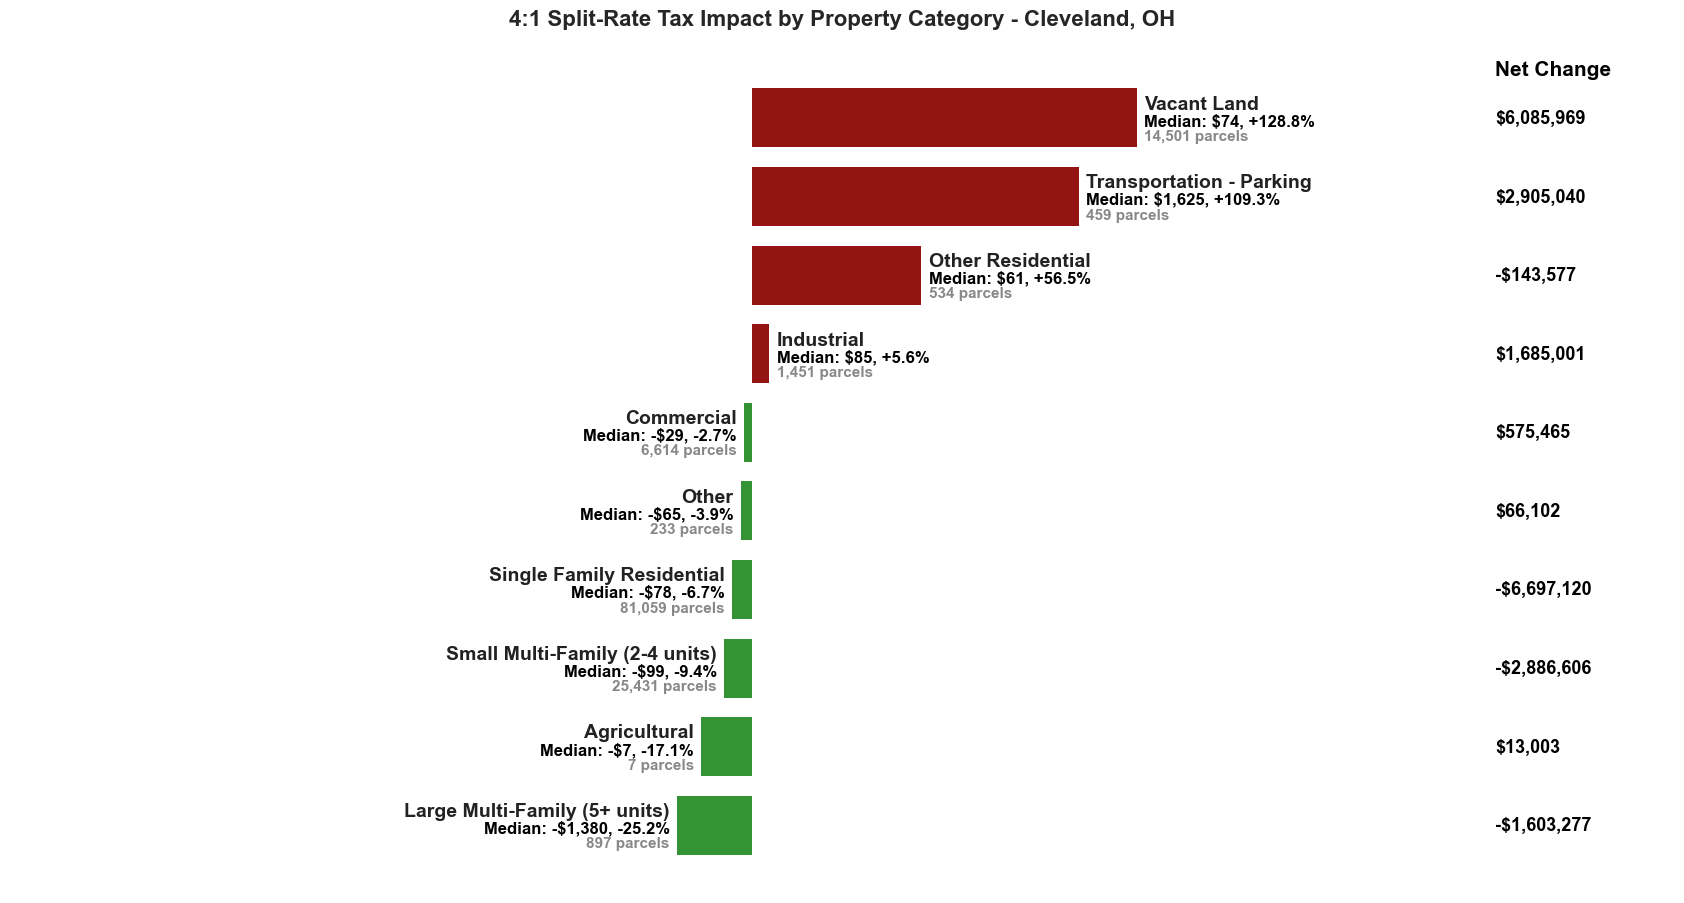

In [11]:
# Property category impact chart (Spokane / Syracuse style, sorted by median tax change percent)
filtered = category_summary[category_summary["median_tax_change_pct"] != 0].copy()
filtered = filtered[filtered["property_count"] > 0]

categories = filtered["PROPERTY_CATEGORY"].tolist()
counts = filtered["property_count"].tolist()
median_pct_change = filtered["median_tax_change_pct"].tolist()
median_dollar_change = filtered["median_tax_change"].tolist()
total_tax_change = filtered["total_tax_change_dollars"].tolist()

sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

bar_colors = ["#8B0000" if val > 0 else "#228B22" for val in median_pct_change]

bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120
fig, ax = plt.subplots(figsize=(17, fig_height))
y = np.arange(len(categories))

ax.barh(
    y,
    median_pct_change,
    color=bar_colors,
    edgecolor="none",
    height=bar_height,
    alpha=0.92,
    linewidth=0,
    zorder=2,
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

cat_offset = 0.18
med_offset = -0.03
count_offset = -0.23
max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

ax.text(
    right_col_x,
    len(categories) - 0.5,
    "Net Change",
    va="bottom",
    ha="left",
    fontsize=15,
    fontweight="bold",
    color="black",
)

for i, (cat, val, count, med_dol, tot_change) in enumerate(
    zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)
):
    med_dol_str = f"${med_dol:,.0f}" if med_dol >= 0 else f"-${abs(med_dol):,.0f}"
    pct_str = f"{val:+.1f}%"
    median_combo = f"Median: {med_dol_str}, {pct_str}"

    if val < 0:
        xpos = val - 2.5
        ha = "right"
    else:
        xpos = val + 2.5
        ha = "left"

    ax.text(xpos, y[i] + cat_offset, cat, va="center", ha=ha, fontsize=14, fontweight="bold", color="#222")
    ax.text(xpos, y[i] + med_offset, median_combo, va="center", ha=ha, fontsize=12, fontweight="bold", color="black")
    ax.text(xpos, y[i] + count_offset, f"{count:,} parcels", va="center", ha=ha, fontsize=11, fontweight="bold", color="#888")

    tot_change_str = f"${tot_change:,.0f}" if tot_change >= 0 else f"-${abs(tot_change):,.0f}"
    ax.text(
        right_col_x,
        y[i],
        tot_change_str,
        va="center",
        ha="left",
        fontsize=13,
        fontweight="bold",
        color="black",
    )

ax.set_xlim(-right_col_x, right_col_x + 60)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("4:1 Split-Rate Tax Impact by Property Category - Cleveland, OH", fontsize=16, fontweight="bold", pad=18)

plt.tight_layout()
plt.show()


In [12]:
vacant_results = analyze_vacant_land(
    df=cleveland_4to1,
    land_value_col="gross_certified_land",
    improvement_value_col="gross_certified_building",
    property_type_col="PROPERTY_CATEGORY",
    vacant_identifier="Vacant Land",
    neighborhood_col="neighborhood_code",
    owner_col="parcel_owner",
    exemption_col="existing_relief_total",
    exemption_flag_col="full_exmp",
)
print_vacant_land_summary(vacant_results)

parking_results = analyze_parking_lots(
    df=cleveland_4to1,
    land_value_col="gross_certified_land",
    improvement_value_col="gross_certified_building",
    property_type_col="PROPERTY_CATEGORY",
    parking_identifier="Transportation - Parking",
    exemption_col="existing_relief_total",
    exemption_flag_col="full_exmp",
)
print_parking_analysis_summary(parking_results)


VACANT LAND ANALYSIS SUMMARY
Total vacant parcels: 14,501
Total vacant land value: $374,497,940
Average vacant land value: $25,826
Vacant land as % of total city land value: 8.0%

Top 5 neighborhoods by vacant land value:
                   count  total_value    avg_value  median_value
neighborhood_code                                               
91121                  3   23657600.0   7885866.67     6615900.0
47187                 16   21682400.0   1355150.00      223400.0
91308                  1   13541400.0  13541400.00    13541400.0
47498                  2   12061000.0   6030500.00     6030500.0
47111                161    8575400.0     53263.35        9800.0

Ownership concentration:
Top 5% of owners control: $276,733,100 (73.9%)
Top 10% of owners control: $308,073,200 (82.3%)
PARKING LOT EFFICIENCY ANALYSIS
Total parking lots: 459
Total parking land value: $235,576,000
Average parking land value: $513,237
Average improvement ratio: 38.2%

Underutilized parking lots (Land val

/Users/gregmiller/Documents/CLE/cle/LVTShift/policy_analysis.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_analysis = tier_df.groupby('land_value_tier').agg({


## Step 6: Adding Geographic Context

Census demographics are joined at the census block-group level using the county FIPS for Cuyahoga County, Ohio:

- County FIPS: `39035`
- ACS year: `2022`

The notebook loads the Census API key from `.env` and then spatially joins Cleveland parcels to block groups using parcel centroids, matching the repo's existing helper logic.


In [13]:
census_api_key = os.getenv("CENSUS_API_KEY")
print("CENSUS_API_KEY loaded:", bool(census_api_key))

census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code="39035",
    year=2022,
    api_key=census_api_key,
)

if census_boundaries.crs is None:
    census_boundaries = census_boundaries.set_crs(epsg=4326)

if cleveland_4to1.crs != census_boundaries.crs:
    cleveland_4to1 = cleveland_4to1.to_crs(census_boundaries.crs)

df_geo = match_to_census_blockgroups(
    gdf=cleveland_4to1,
    census_gdf=census_boundaries,
)

print(f"Number of parcels with geometry: {len(df_geo):,}")
print(f"Number of census block groups: {len(census_boundaries):,}")
print("Key demographic columns present:")
display([col for col in ["std_geoid", "median_income", "minority_pct", "black_pct", "total_pop"] if col in df_geo.columns])


CENSUS_API_KEY loaded: True


Number of parcels with geometry: 131,186
Number of census block groups: 15,465
Key demographic columns present:


['std_geoid', 'median_income', 'minority_pct', 'black_pct', 'total_pop']

## Step 7: Demographic and Equity Analysis

These cells mirror the census-progressivity bar charts used in Syracuse and related notebooks: one set for neighborhood income quintiles and another for neighborhood minority-share quintiles.


In [14]:
bg_summary = calculate_block_group_summary(
    df=df_geo,
    group_col="std_geoid",
    tax_change_col="tax_change",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
)

display(bg_summary.head())


,std_geoid,total_tax_change,parcel_count,mean_tax_change,mean_tax_change_pct,total_current_tax,total_new_tax,median_income,minority_pct,black_pct,total_tax_change_pct
1,390351011012,-48316.082573,80,-603.951032,13.071484,267389.61,2.190735e+05,26477.0,73.57,42.52,-18.069544
2,390351011021,-109956.620085,177,-621.223842,2.004661,878997.48,7.690409e+05,63844.0,15.13,6.49,-12.509321
3,390351011022,-92377.399774,379,-243.739841,-4.279778,1188590.46,1.096213e+06,83858.0,17.42,0.00,-7.772013
4,390351011023,-40484.113208,206,-196.524821,-2.938539,673658.80,6.331747e+05,52914.0,31.20,0.61,-6.009587
5,390351011024,-65502.935928,269,-243.505338,16.623014,2329721.02,2.264218e+06,60291.0,33.98,17.32,-2.811621


In [15]:
def create_quintile_summary(df_input, value_col, labels=None):
    if labels is None:
        labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"]

    work = df_input[(df_input[value_col].notna())].copy()
    if value_col == "median_income":
        work = work[work[value_col] > 0].copy()

    work["quintile"] = pd.qcut(work[value_col], 5, labels=labels, duplicates="drop")
    summary = work.groupby("quintile").agg(
        count=("tax_change", "count"),
        mean_tax_change=("tax_change", "mean"),
        median_tax_change=("tax_change", "median"),
        mean_tax_change_pct=("tax_change_pct", "mean"),
        median_tax_change_pct=("tax_change_pct", "median"),
        mean_value=(value_col, "mean"),
    ).reset_index()
    return summary


def plot_upside_down_quintile_bars(summary_df, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    vals = summary_df["median_tax_change_pct"].astype(float)
    labels = summary_df["quintile"]

    colors = sns.color_palette("Greens", n_colors=len(vals))
    color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

    bars = ax.bar(
        labels,
        np.abs(vals),
        color=color_map,
        edgecolor="black",
        width=0.7,
    )

    ax.invert_yaxis()
    ax.yaxis.set_visible(False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title, weight="bold", pad=30)
    sns.despine(left=True, right=True, top=True, bottom=True)

    for bar, val in zip(bars, vals):
        ax.annotate(
            f"{val:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="center",
            fontsize=13,
            color="black",
            fontweight="bold",
        )

    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    plt.xticks(fontweight="bold")

    ymax = np.abs(vals).max() * 1.1 if len(vals) else 1
    ax.set_ylim(ymax, 0)

    plt.tight_layout()
    plt.show()


Tax impact by income quintile (excluding vacant land):


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_62207/362747095.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work.groupby("quintile").agg(


,quintile,count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),20699,-81.651411,-58.329996,-0.272767,-7.487338,21840.661916
1,Q2,20834,-93.863422,-58.843743,-2.163703,-6.470944,32797.730777
2,Q3,20757,-29.250043,-75.172605,-1.570971,-7.136231,40879.245508
3,Q4,20792,-142.386447,-93.471540,-2.713252,-6.955617,51780.694450
4,Q5 (Highest),20275,-28.027092,-151.168789,-0.251355,-8.007767,80657.910432


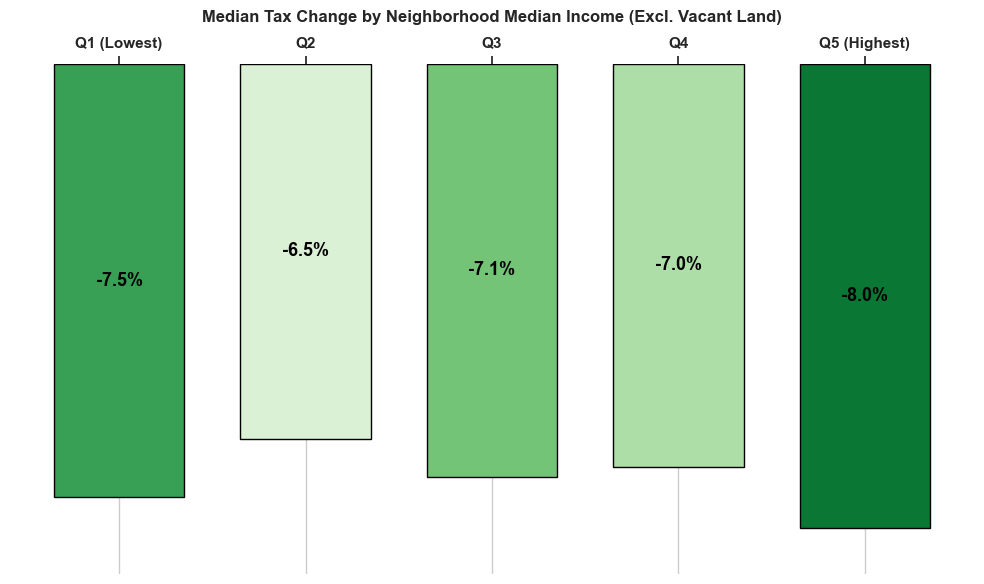

In [16]:
# Excluding vacant land, all remaining property categories.
non_vacant_gdf = df_geo[df_geo["PROPERTY_CATEGORY"] != "Vacant Land"].copy()

print("Tax impact by income quintile (excluding vacant land):")
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, "median_income")
display(non_vacant_income_quintile_summary)

plot_upside_down_quintile_bars(
    non_vacant_income_quintile_summary,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)",
)


Tax impact by minority-share quintile (excluding vacant land):


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_62207/362747095.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work.groupby("quintile").agg(


,quintile,count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),23445,-59.843505,-134.714217,0.501443,-7.097364,22.031965
1,Q2,23118,-32.038940,-102.646265,-1.707895,-7.235481,44.467908
2,Q3,23399,-50.189212,-78.094877,-0.367698,-6.785381,66.533416
3,Q4,23414,-91.881740,-51.487270,-0.613162,-6.926152,91.971227
4,Q5 (Highest),22910,-86.745153,-56.065574,-2.056342,-7.877827,99.655952


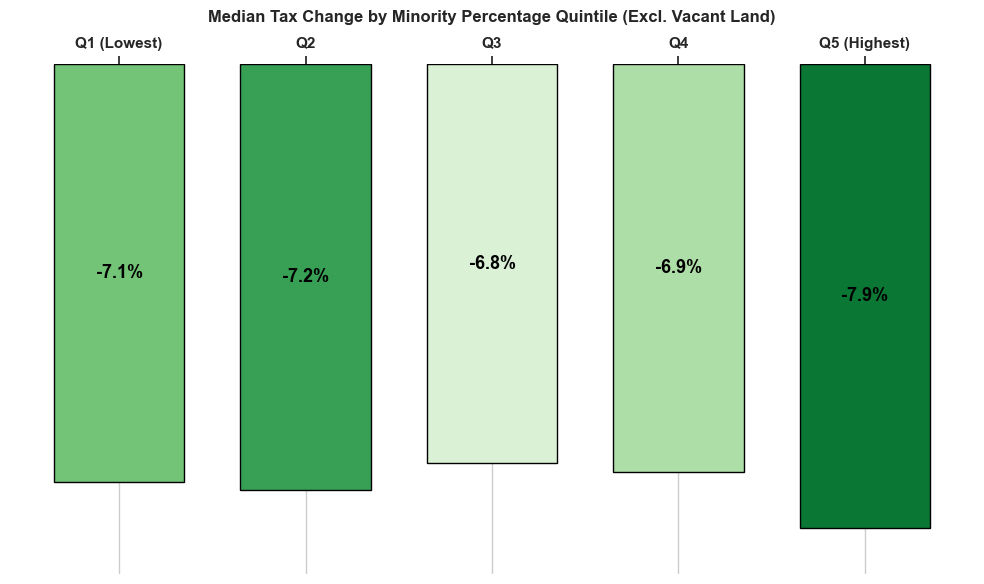

In [17]:
print("Tax impact by minority-share quintile (excluding vacant land):")
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, "minority_pct")
display(non_vacant_minority_quintile_summary)

plot_upside_down_quintile_bars(
    non_vacant_minority_quintile_summary,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)",
)


## Step 8: Single-Family Progressivity Analysis

This section reruns the progressivity lookups for **single-family housing only**, while also excluding vacant land. Since the subset is already limited to `Single Family Residential`, the vacant-land exclusion is satisfied by construction and kept explicit in the code.


In [18]:
df_single_family = df_geo[
    (df_geo["PROPERTY_CATEGORY"] == "Single Family Residential")
    & (df_geo["PROPERTY_CATEGORY"] != "Vacant Land")
].copy()

print(f"Single-family parcels in demographic analysis: {len(df_single_family):,}")

non_vacant_income_quintile_summary_sf = create_quintile_summary(df_single_family, "median_income")
non_vacant_minority_quintile_summary_sf = create_quintile_summary(df_single_family, "minority_pct")

print("\nSingle-family tax impact by income quintile:")
display(non_vacant_income_quintile_summary_sf)

print("\nSingle-family tax impact by minority percentage quintile:")
display(non_vacant_minority_quintile_summary_sf)


Single-family parcels in demographic analysis: 81,059



Single-family tax impact by income quintile:


/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_62207/362747095.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work.groupby("quintile").agg(
/var/folders/jb/s1bhbc2x3dgbhdvtbnz335sc0000gn/T/ipykernel_62207/362747095.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work.groupby("quintile").agg(


,quintile,count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14550,-63.464295,-48.453893,-0.409966,-6.467445,23111.002680
1,Q2,14388,-69.354110,-51.668208,-2.564066,-5.720651,34678.681679
2,Q3,14473,-81.199479,-75.596873,-1.804307,-6.351955,43023.994403
3,Q4,14854,-102.139921,-90.810714,-3.404925,-6.671493,55072.071294
4,Q5 (Highest),14080,-114.482147,-152.806103,-1.183216,-8.098582,83513.075355



Single-family tax impact by minority percentage quintile:


,quintile,count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),16622,-131.406203,-140.944718,-2.409207,-7.356995,20.496413
1,Q2,15917,-74.644578,-90.371010,-1.036575,-6.308563,41.635411
2,Q3,16205,-65.598263,-67.336311,-0.280066,-5.802387,62.462409
3,Q4,16250,-70.105396,-50.188955,-1.266705,-6.568968,90.708988
4,Q5 (Highest),16065,-69.874643,-54.434500,-2.179259,-7.596360,99.669028


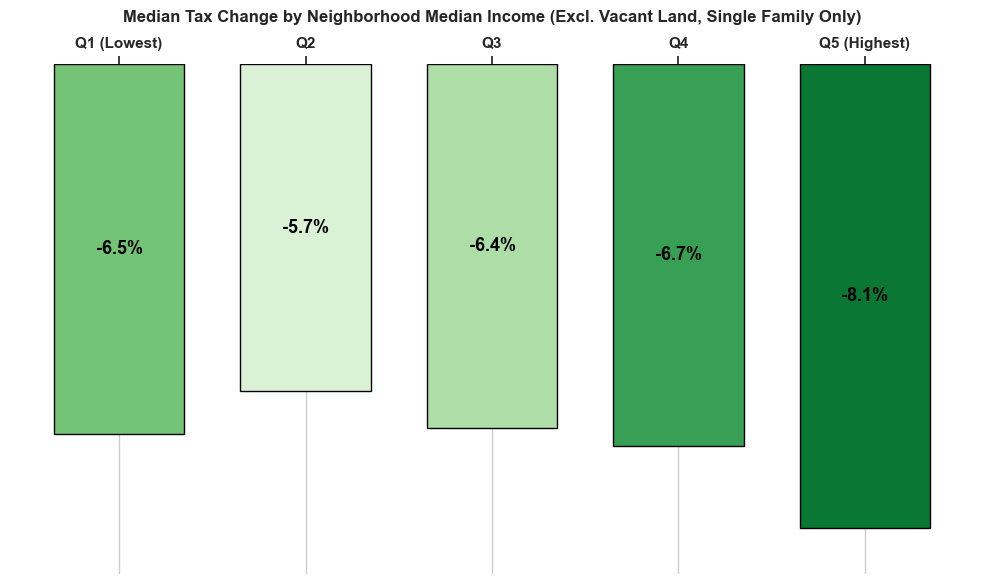

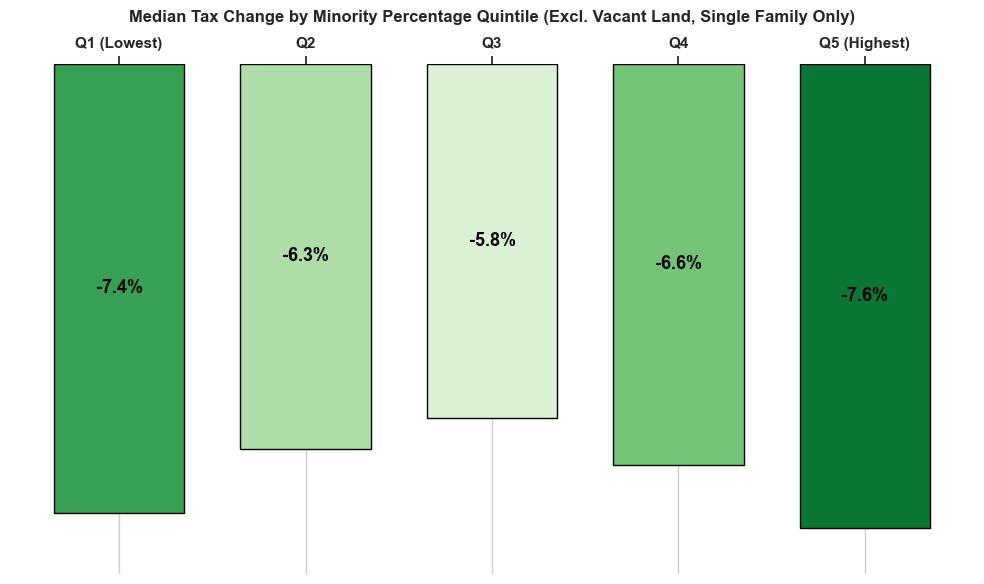

In [19]:
plot_upside_down_quintile_bars(
    non_vacant_income_quintile_summary_sf,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land, Single Family Only)",
)

plot_upside_down_quintile_bars(
    non_vacant_minority_quintile_summary_sf,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land, Single Family Only)",
)


In [20]:
modeled_output_path = data_dir / f"cleveland_modeled_4to1_{datetime.now().strftime('%Y%m%d')}.parquet"
cleveland_4to1.to_parquet(modeled_output_path, index=False)
print(f"Saved modeled 4:1 output to {modeled_output_path}")
modeled_output_path


Saved modeled 4:1 output to /Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/cleveland/cleveland_modeled_4to1_20260310.parquet


PosixPath('/Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/cleveland/cleveland_modeled_4to1_20260310.parquet')